# Analysis — N Particles

In [35]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from aux_functions import shorten_points
from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, get_xf_yf_fund, get_mean_amp_and_phase, get_fft

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [36]:
filenames_all = fetch_data_filenames("./20-05-26")
# filenames_all = fetch_data_filenames("./23-05-26")

In [37]:
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
    ]

In [38]:
#Populate particle list
num_particles = 1
p_list = [
    {
        "p_label": p_id+1,
        "p_data": [
            extract_data_info_from_path(p_data_path)
            for p_data_path in filenames_all
            if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)
        ]
    }
    for p_id in range(num_particles)
]

In [39]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas


  Processing particle 1  


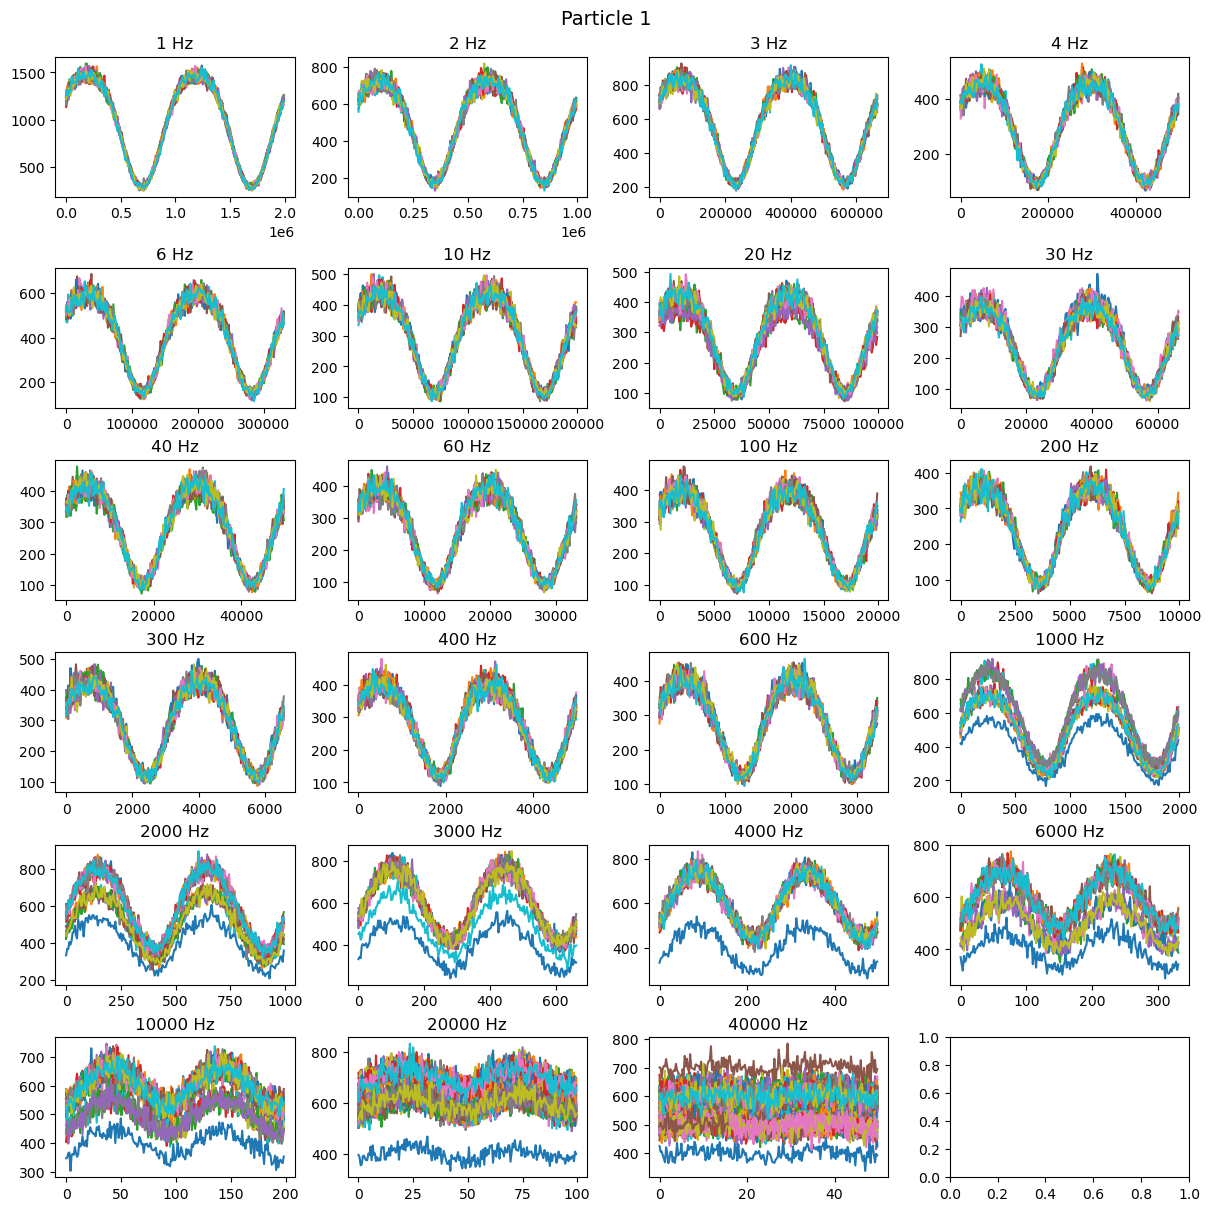

In [40]:
def time_domain_visual_verification(particles: list):

    for p_idx, p_dic in enumerate(particles):
        particle_label = f"Particle {p_dic['p_label']}"
        # correct = adj_phase_correction[p_idx] if p_idx < len(adj_phase_correction) else False

        print(f"\n{'='*50}")
        print(f"  Processing particle {p_dic['p_label']}  ")
        print(f"{'='*50}")

        omegas      = []
        phase_diffs = []

        # ---- Subplots de verificação visual ----
        fig, axs = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)
        fig.suptitle(f"Particle {p_dic["p_label"]}", fontsize=14)

        # data = p_dic["p_data"]

        for index, step_data in enumerate(p_dic["p_data"]):
            freq = step_data["freq"]
            i, j = divmod(index, cols)
            omega = 2 * np.pi * float(freq) * 1e-6
            omegas.append(omega)

            # Colocar para fazer calcular fases média

            ax = axs[i, j]
            for idx_rep, rep in enumerate(step_data["data"]):
                ax.plot(rep[:,0], rep[:,1])

            ax.set_title(f"{freq} Hz")


        plt.show()

time_domain_visual_verification(p_list)

## Get mean phases and errors

In [41]:
#Calculate list of phasors for the laser and all measurements
for step in exc_data_npy:
  freq = step["freq"]
  step["fft_amp_list"] = []
  for meas_idx, meas in enumerate(step["data"]):
    _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
    step["fft_amp_list"].append(amp)

In [42]:
# Get mean phase and error for each particle and each step (freq) 
for step in exc_data_npy:
    freq = step["freq"]
    amp_list = step["fft_amp_list"]
    _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
    step["mean_fft_info"] = [freq, phase, phase_error]

In [43]:
#Calculate list of phasors for all particles and all measurements
for p in p_list:
  for step in p["p_data"]:
    freq = step["freq"]
    step["fft_amp_list"] = []
    for meas_idx, meas in enumerate(step["data"]):
      _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
      step["fft_amp_list"].append(amp)

In [44]:
# Get mean phase and error for each particle and each step (freq) 
for p in p_list:
    for step in p["p_data"]:
        freq = step["freq"]
        amp_list = step["fft_amp_list"]
        _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
        step["mean_fft_info"] = [freq, phase, phase_error]

## Comparison — all particles

In [45]:
def get_error_bar(exc_data, p_list):
    exc_mean_phase = np.array([
            step["mean_fft_info"]
            #[freq, phase, phase_error]
            for step in exc_data
        ])
    error_exc = exc_mean_phase[:,2]
    # print(error_exc)

    for p in p_list:
        # if p["p_label"] !=1: continue
        p_mean_phase = np.array([
            step["mean_fft_info"]
            for step in p["p_data"]
            ])
        
        if (p_mean_phase[:,0]-exc_mean_phase[:,0]).sum() != 0.:
            print("Deu ruim!")
            return None
        else:
            pd_list = np.unwrap(p_mean_phase[:,1]-exc_mean_phase[:,1])
            pd_error = np.hypot(
                p_mean_phase[:,2],
                exc_mean_phase[:,2]
            )

        p["error_bar"] = np.column_stack((p_mean_phase[:,0], pd_list, pd_error))

get_error_bar(exc_data_npy, p_list)

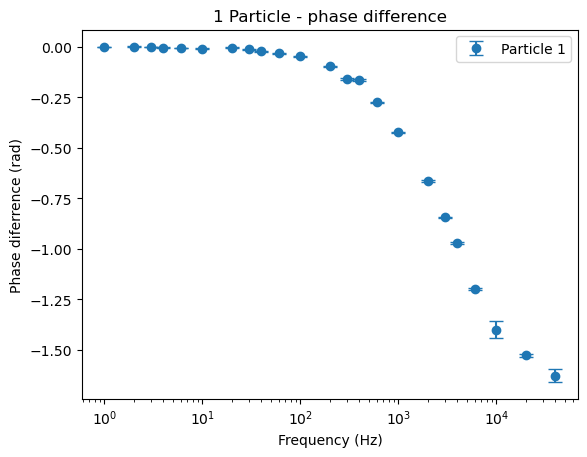

In [46]:
def plot_phase_difference(particles: list, p_to_skip = [], freqs_to_skip = []):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for p_id, p in enumerate(particles):
        if p["p_label"] in p_to_skip: continue
        color = colors[p_id % len(colors)]
        # p["error_bar"]
        label_added = False
        for idx, error_point in enumerate(p["error_bar"]):
            # Skip frequencies larger than 20kHz
            if (error_point[0] in freqs_to_skip): 
                # print(f"Não foi calculado pra freq: {error_point[0]}Hz")
                continue
            
            current_label = f"Particle {p['p_label']}" if not label_added else None

            plt.errorbar(
                error_point[0],
                error_point[1],
                yerr=error_point[2],
                label=current_label,
                fmt='o',
                capsize=5,
                color=color,
            )
            label_added = True
        # plt.title(f"Particle {p['p_label']}  - phase difference")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Phase diferrence (rad)")
        plt.xscale("log")
    
    if len(particles)>1:
        plt_title = f"{len(particles)} Particles - phase difference" 
    else:
        plt_title = f"{len(particles)} Particle - phase difference" 

    plt.title(plt_title)
    plt.legend()
    plt.show()

plot_phase_difference(p_list, p_to_skip=[], freqs_to_skip=[])

## Signal-Noise relation

In [47]:
def get_snr_db(time, curve):
    """
    Calcula a Relação Sinal-Ruído (SNR) em dB.
    Considera o maior pico da FFT como o 'sinal' e o restante como 'ruído'.
    """
    # 1. Obtém a FFT usando a sua função existente
    xf, yf = get_fft(time, curve)
    
    # 2. Ignora a componente DC e frequências negativas
    mask = xf > 0
    xf = xf[mask]
    yf = yf[mask]
    
    # 3. Calcula o espectro de potência (módulo ao quadrado)
    power = np.abs(yf)**2
    
    # 4. Identifica a potência do Sinal (o maior pico)
    idx_fund = np.argmax(power) # Pega o índice do maior valor
    p_signal = power[idx_fund]
    
    # 5. Identifica a potência do Ruído (Potência total - Potência do sinal)
    p_noise = np.sum(power) - p_signal
    
    # Tratamento de segurança: se o sinal for uma senoide perfeita simulada,
    # o ruído pode ser teoricamente zero (ou próximo do limite da máquina).
    if p_noise <= 1e-15:
        return float('inf') 
        
    # 6. Calcula a razão em dB
    snr_db = 10 * np.log10(p_signal / p_noise)
    
    return snr_db

def plot_time_and_freq_domain(time, lum_curve, laser_curve):
    """Plot time and frequency domain of the luminescence and laser curves"""
    # Suponho que a função get_fft já esteja definida no seu código
    xf_laser, yf_laser = get_fft(time, laser_curve)
    xf_lum, yf_lum = get_fft(time, lum_curve)
    
    # Filtering only positive frequencies
    lum_mask = xf_lum > 0
    xf_lum = xf_lum[lum_mask]
    yf_lum = yf_lum[lum_mask]
    laser_mask = xf_laser > 0
    xf_laser = xf_laser[laser_mask]
    yf_laser = yf_laser[laser_mask]

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # --- DOMÍNIO DO TEMPO ---
    # Eixo principal (Esquerdo - Verde/Lum)
    axs[0].set_xlabel("Time ($\mu$s)")
    axs[0].set_ylabel("Luminescence (a.u.)", color="tab:green")
    line1 = axs[0].plot(time*(1e-6), lum_curve, color="tab:green", label="lum")
    axs[0].tick_params(axis='y', labelcolor="tab:green")
    axs[0].set_title("Time Domain")

    # Eixo secundário (Direito - Vermelho/Laser)
    ax0_twin = axs[0].twinx()
    ax0_twin.set_ylabel("Laser (a.u.)", color="tab:red")
    line2 = ax0_twin.plot(time*(1e-6), laser_curve, color="tab:red", label="laser")
    ax0_twin.tick_params(axis='y', labelcolor="tab:red")

    # Juntando as legendas dos dois eixos
    lines_time = line1 + line2
    labels_time = [l.get_label() for l in lines_time]
    axs[0].legend(lines_time, labels_time, loc="best")


    # --- DOMÍNIO DA FREQUÊNCIA ---
    # Eixo principal (Esquerdo - Verde/Lum)
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].set_ylabel("Lum Amplitude", color="tab:green")
    line3 = axs[1].plot(xf_lum, np.abs(yf_lum), color="tab:green", label="lum")
    axs[1].tick_params(axis='y', labelcolor="tab:green")
    axs[1].set_title("Frequency Domain")

    # Eixo secundário (Direito - Vermelho/Laser)
    ax1_twin = axs[1].twinx()
    ax1_twin.set_ylabel("Laser Amplitude", color="tab:red")
    line4 = ax1_twin.plot(xf_laser, np.abs(yf_laser), color="tab:red", label="laser")
    ax1_twin.tick_params(axis='y', labelcolor="tab:red")

    # Juntando as legendas dos dois eixos
    lines_freq = line3 + line4
    labels_freq = [l.get_label() for l in lines_freq]
    axs[1].legend(lines_freq, labels_freq, loc="best")

    plt.show()

freq: 10Hz
SNR: 15.127527417732868


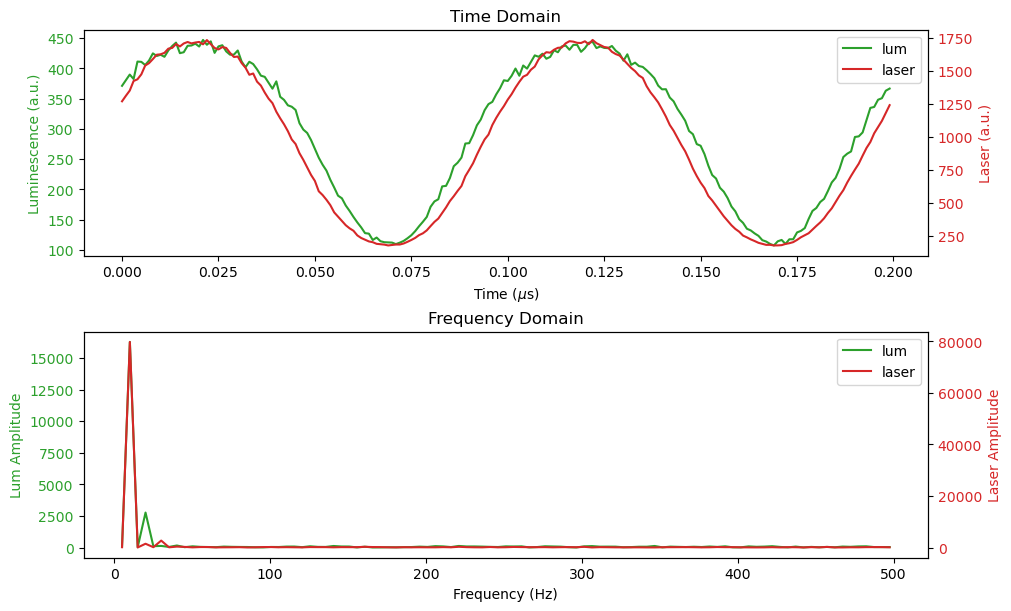

freq: 20Hz
SNR: 15.319873479963938


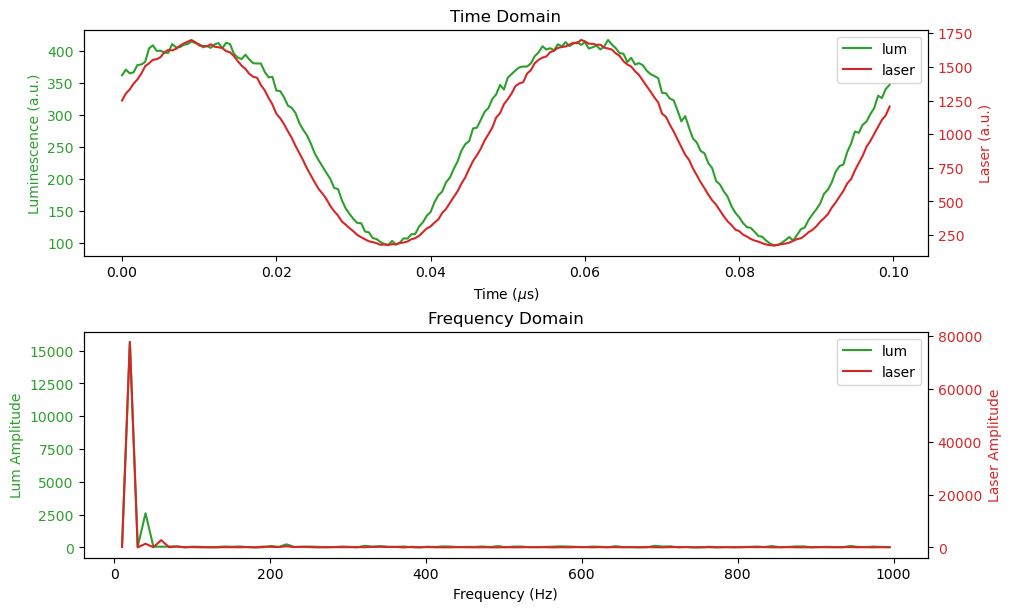

freq: 30Hz
SNR: 15.930263511381241


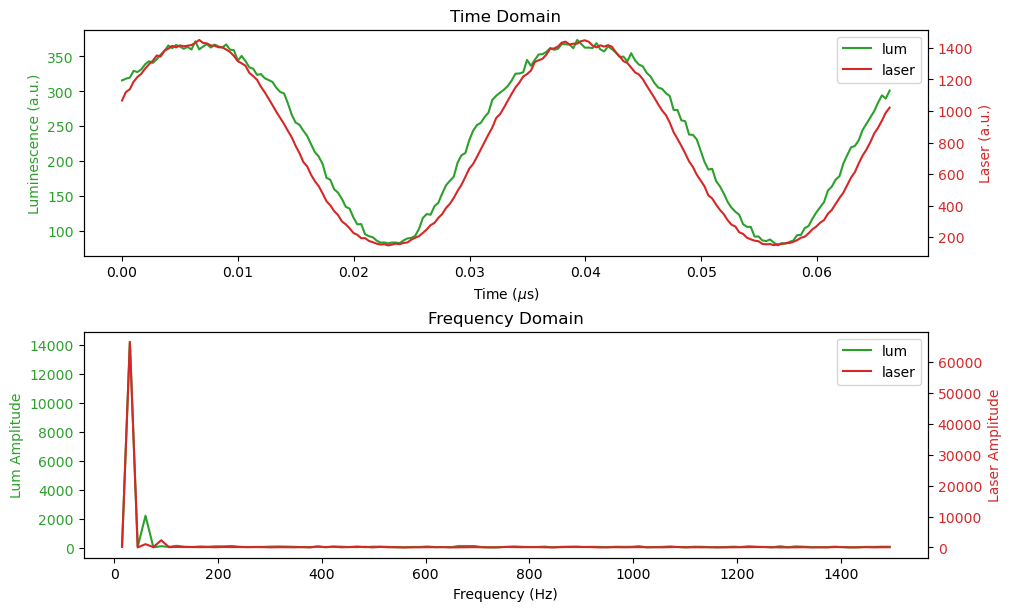

freq: 40Hz
SNR: 15.310642287453541


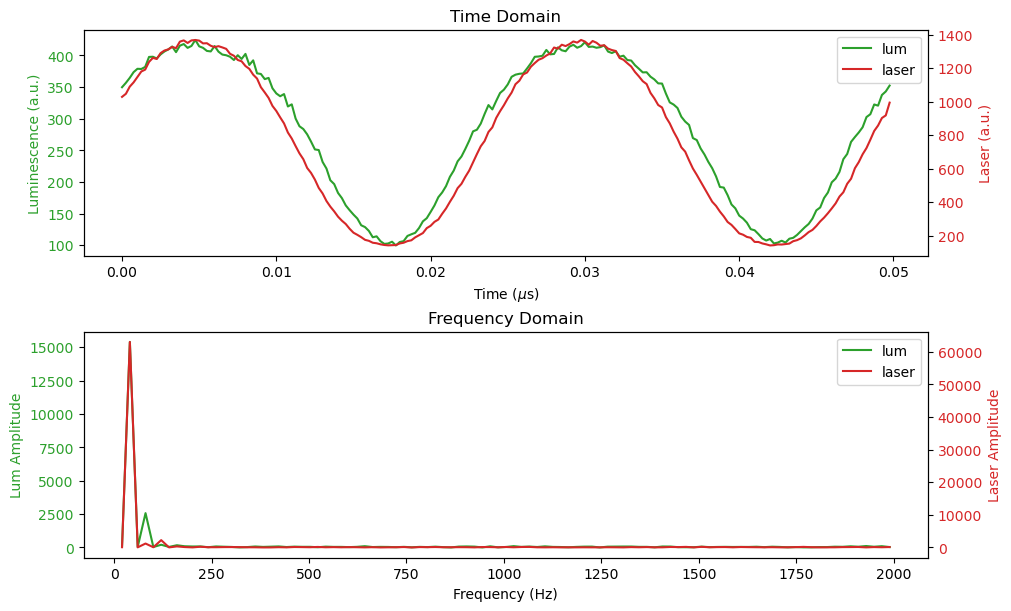

freq: 60Hz
SNR: 15.856602684608559


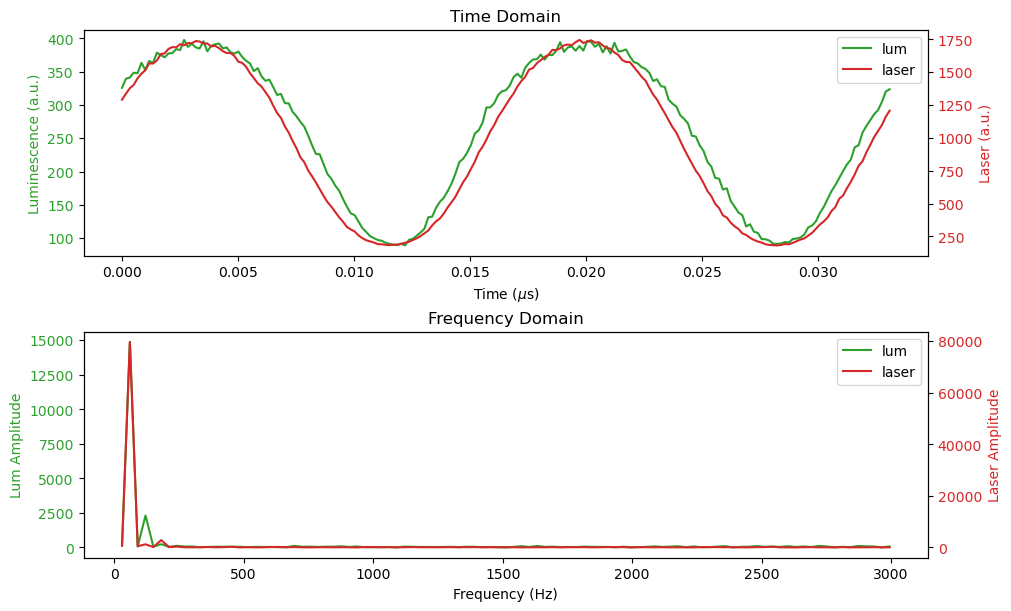

freq: 100Hz
SNR: 15.381952436583513


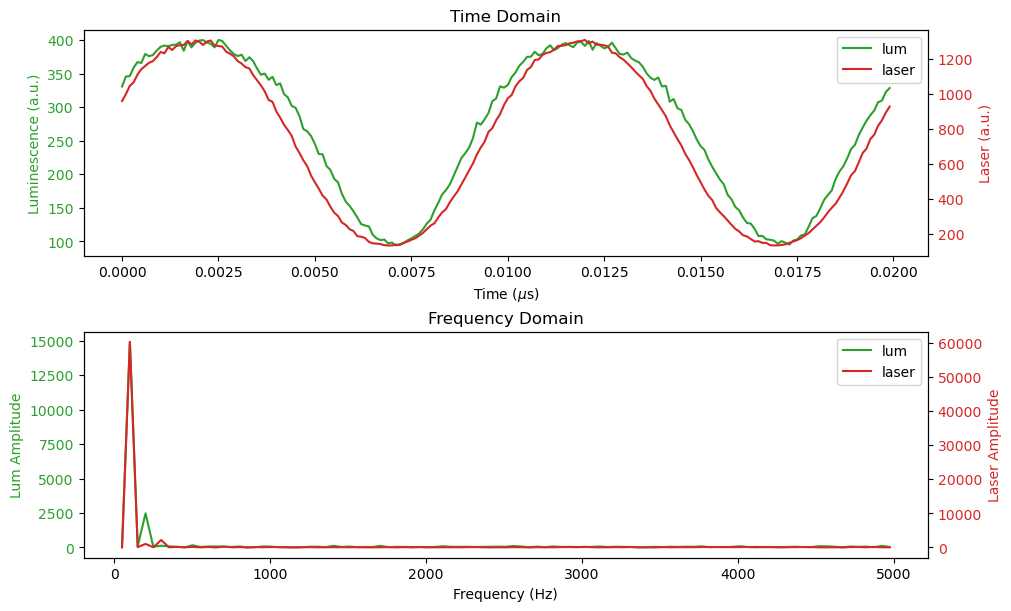

freq: 200Hz
SNR: 15.79276140931109


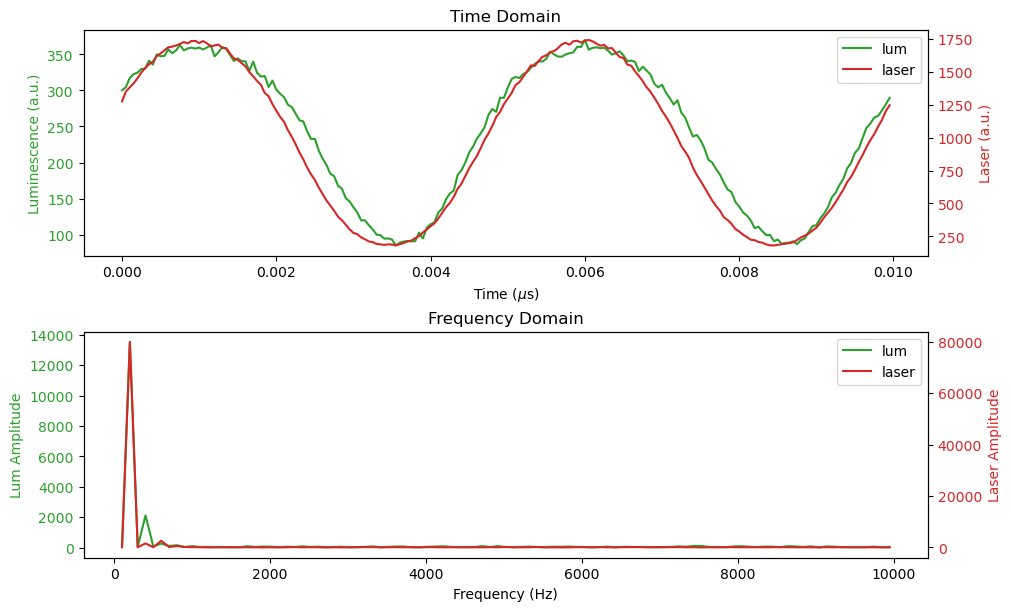

freq: 300Hz
SNR: 15.95737240754753


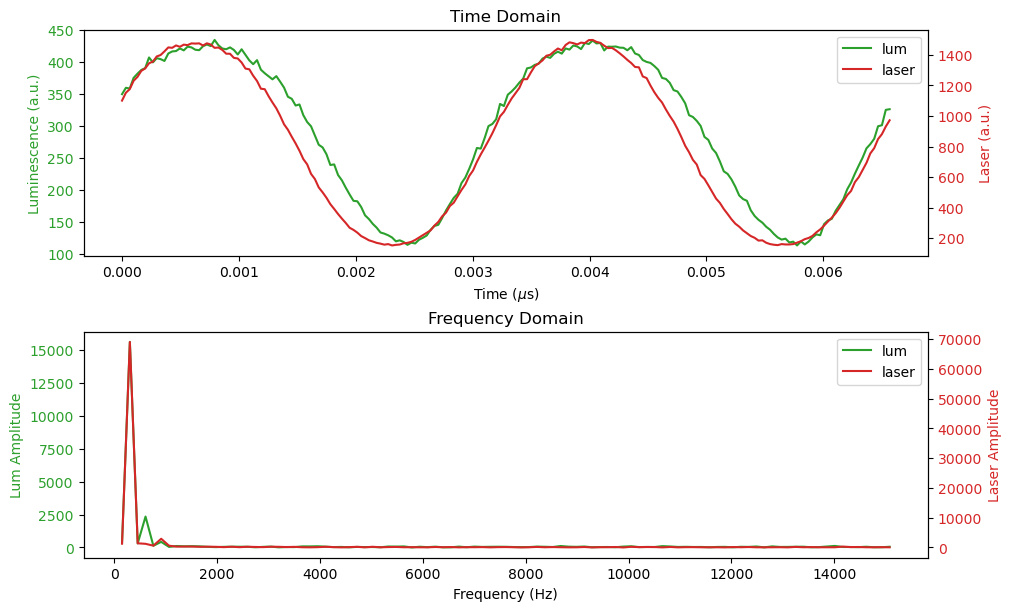

freq: 400Hz
SNR: 15.078600824331192


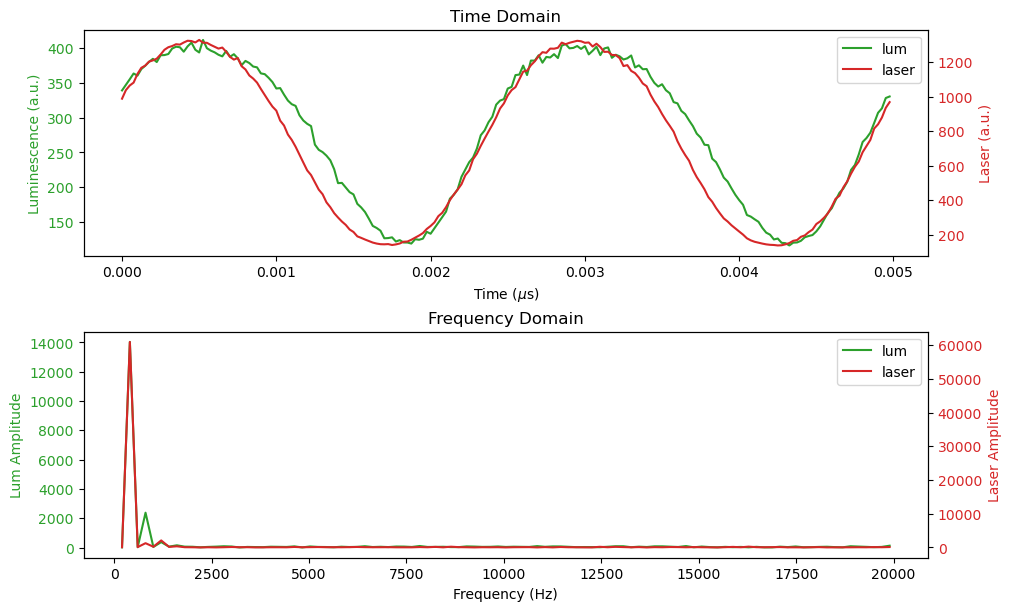

freq: 600Hz
SNR: 16.37117577698097


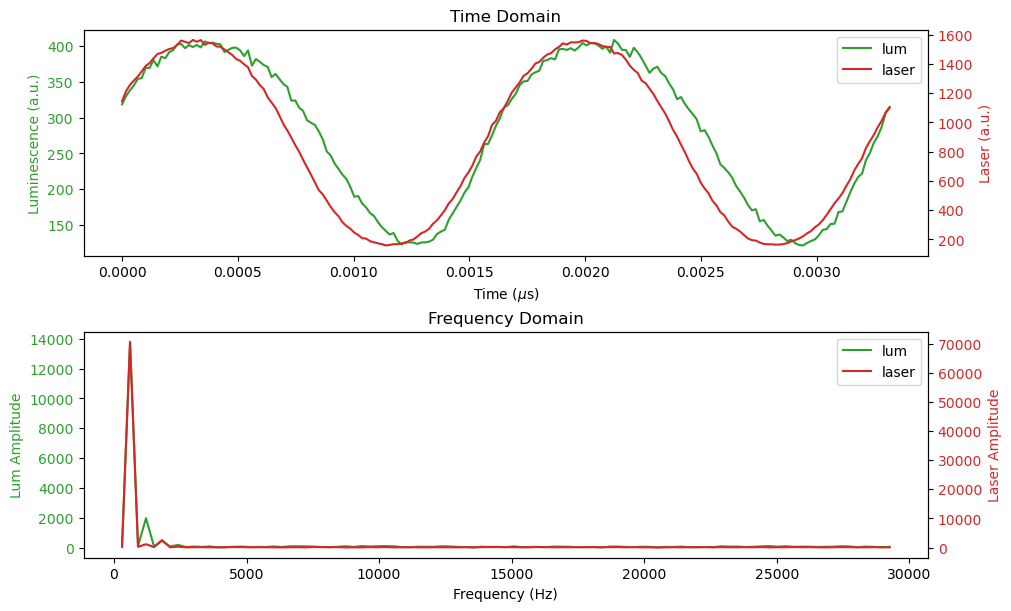

freq: 1000Hz
SNR: 18.127501007328288


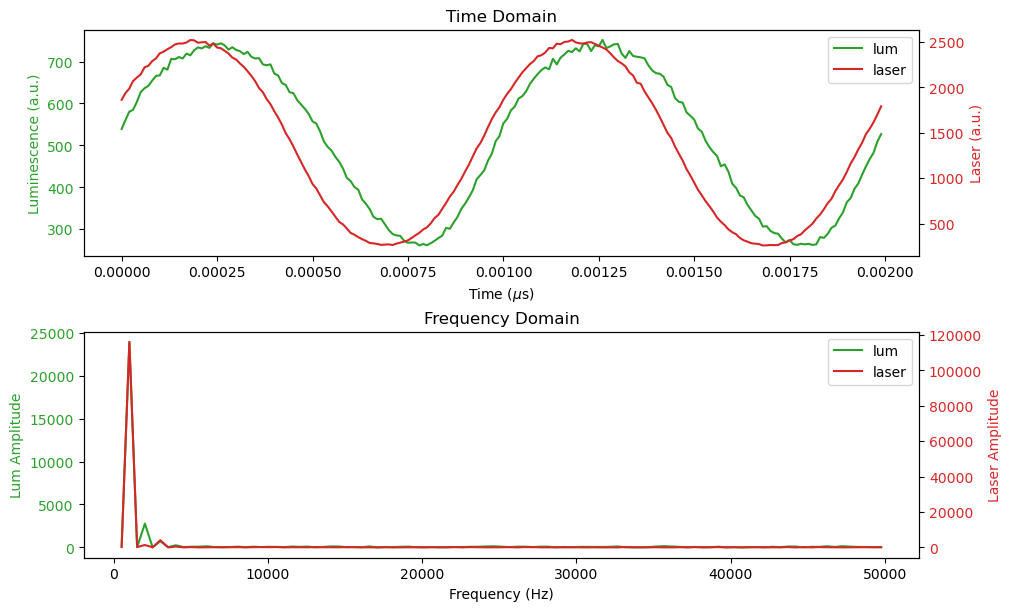

freq: 2000Hz
SNR: 20.085285146836117


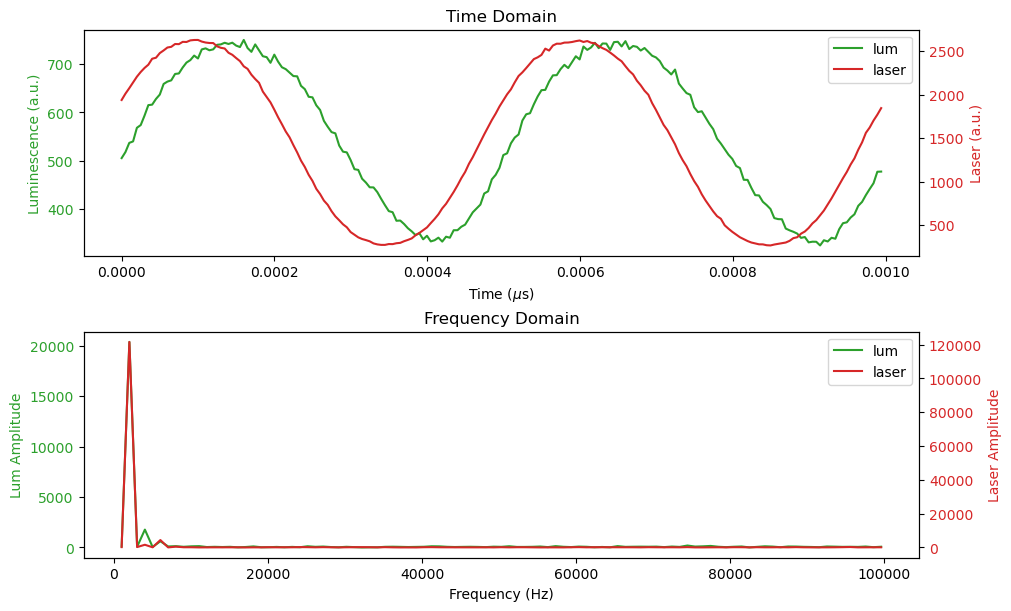

freq: 3000Hz
SNR: 21.25753188114347


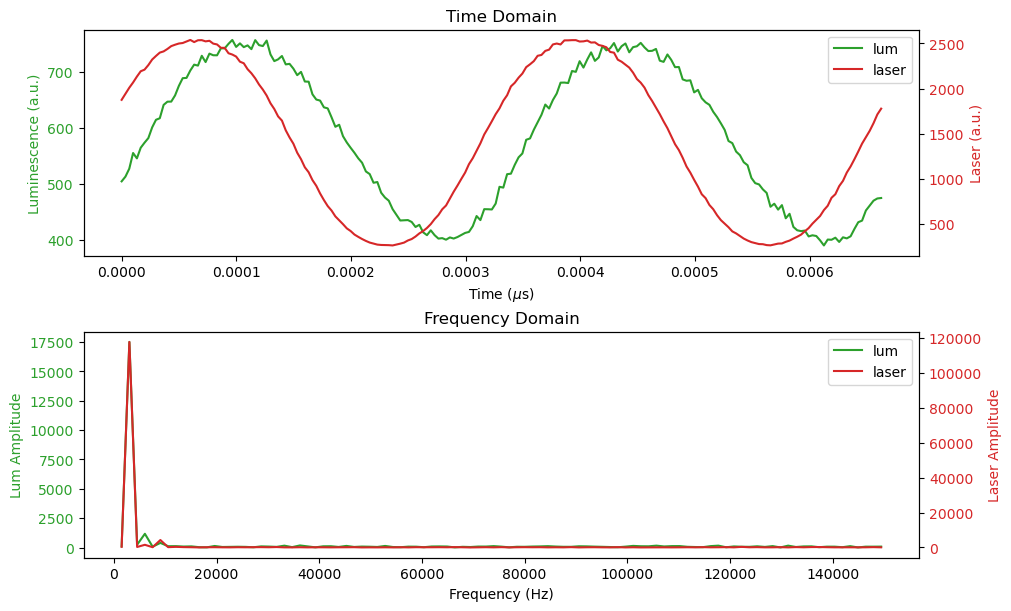

freq: 4000Hz
SNR: 22.49808834178198


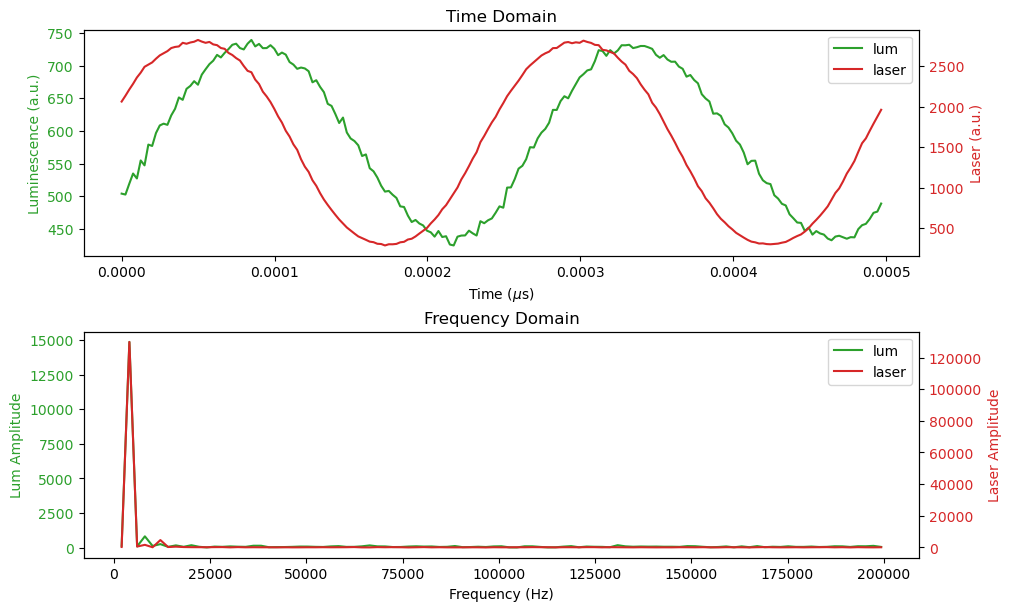

freq: 6000Hz
SNR: 22.198998316166453


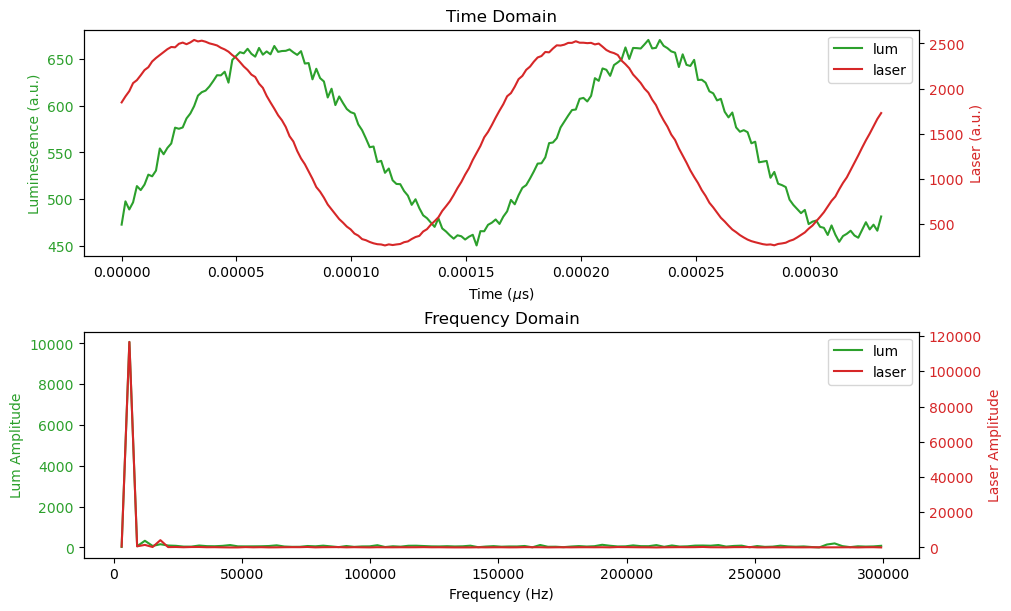

freq: 10000Hz
SNR: 20.44523457911074


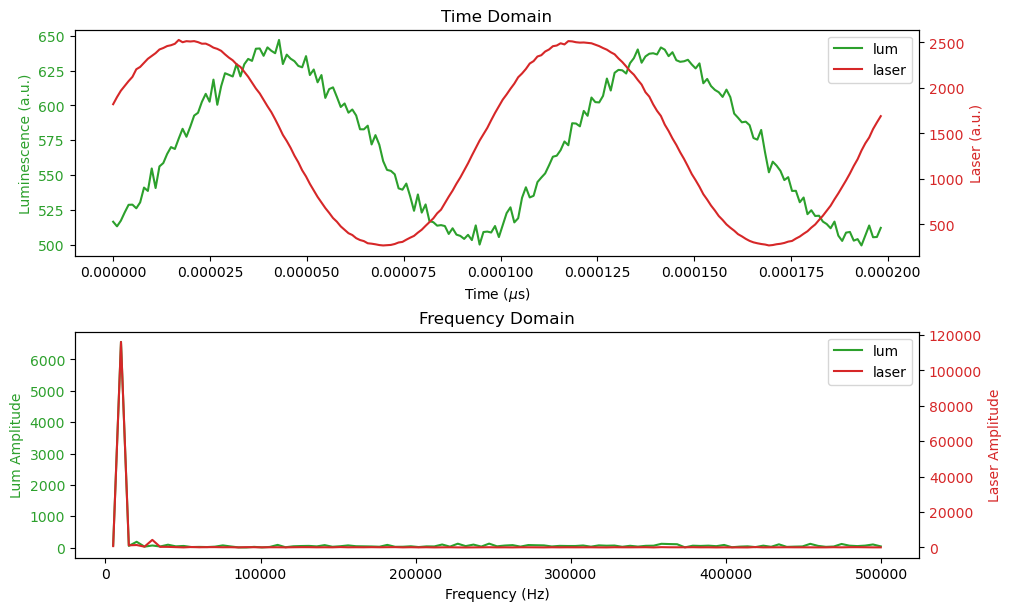

freq: 20000Hz
SNR: 20.076550927364178


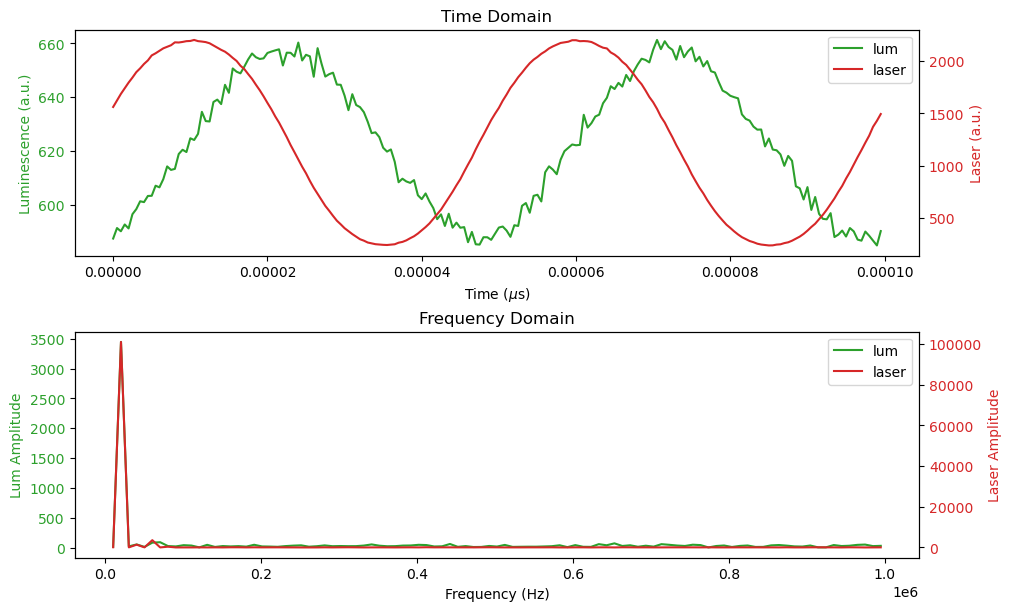

freq: 40000Hz
SNR: 13.460606417000584


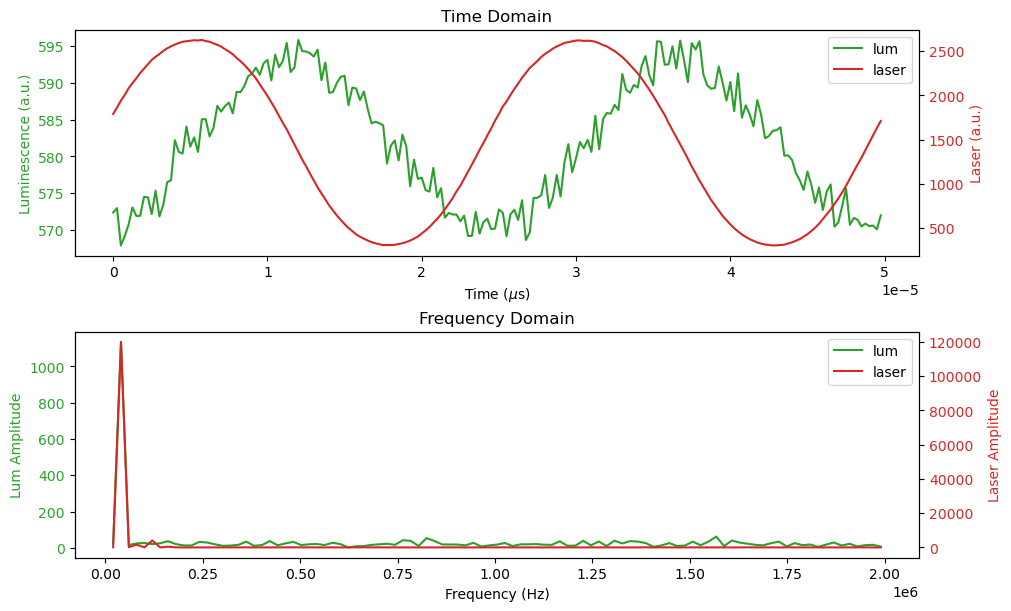

In [48]:
p_idx = 0

for step_idx, step in enumerate(p_list[p_idx]["p_data"]):
    if step["freq"] < 10: continue
    print(f"freq: {step["freq"]}Hz")

    signal = np.array(step["data"])
    laser_signal = np.array(next(exc["data"] for exc in exc_data_npy if exc["freq"] == step["freq"]))
    
    # print(signal[0,:,0])
    print(f"SNR: {get_snr_db(signal[0,:,0], signal[:,:,1].mean(axis=0))}")
    plot_time_and_freq_domain(
        signal[0,:,0], 
        signal[:,:,1].mean(axis=0), 
        laser_signal[:,:,1].mean(axis=0)
        )
    # plt.plot(signal[0,:,0], signal[:,:,1].mean(axis=0))
    plt.show()
    # print(.shape)
    # for meas_idx, meas in enumerate(step["data"]):
    #     # if meas_idx != 0: continue
    #     print(get_snr_db(meas[:,0], meas[:,1]))
    # # print(step["fft_amp_list"])